In [1]:
import pybullet as p
import numpy as np
import sys
from pathlib import Path
import os
import matplotlib.pyplot as plt
import time
from typing import List

In [2]:
datalabs_path = Path.cwd().parent
sys.path.insert(0, str(datalabs_path))

# Import the class
from simulation.cloned.sim_class import Simulation

# Change to the directory where sim_class.py expects to be run from
original_dir = Path.cwd()
sim_dir = datalabs_path / "simulation" / "cloned"
os.chdir(sim_dir)

In [3]:
# PID controller class
class PID:
    def __init__(self, kp, ki, kd):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.reset()
    
    def reset(self):
        self.integral = 0
        self.prev_error = 0
    
    def compute(self, error, dt=1.0):
        self.integral += error * dt
        derivative = (error - self.prev_error) / dt
        output = self.kp * error + self.ki * self.integral + self.kd * derivative
        self.prev_error = error
        return output

In [4]:
sim = Simulation(num_agents=1)

In [7]:
# PID parameters
kp = 20
ki = 0  
kd = 1

# Create PID controllers for each axis
pid_x = PID(kp, ki, kd)
pid_y = PID(kp, ki, kd)
pid_z = PID(kp, ki, kd)

# Workspace bounds
x_bounds = (-0.187, 0.253)
y_bounds = (-0.171, 0.220)
z_bounds = (0.170, 0.289)

# Random target
target_x = np.random.uniform(*x_bounds)
target_y = np.random.uniform(*y_bounds)
target_z = np.random.uniform(*z_bounds)
target = np.array([target_x, target_y, target_z])

print(f"Target: X={target_x:.4f}, Y={target_y:.4f}, Z={target_z:.4f}")

# Reset to start position
sim.set_start_position(0, 0, 0.15)

# Run control loop
max_steps = 1500
tolerance = 0.001  # 1mm
max_velocity = 0.5

positions_x = []
positions_y = []
positions_z = []
robot_id = sim.robotIds[0]

print(f"\n{'='*80}")
print(f"PID CONTROL - Moving to Target")
print(f"{'='*80}")
print(f"Target: X={target[0]:.4f}m, Y={target[1]:.4f}m, Z={target[2]:.4f}m")
print(f"{'='*80}\n")

for step in range(max_steps):
    # Get current position
    states = sim.get_states()
    pos = states[f'robotId_{robot_id}']['pipette_position']
    current_pos = np.array([pos[0], pos[1], pos[2]])
    
    positions_x.append(current_pos[0])
    positions_y.append(current_pos[1])
    positions_z.append(current_pos[2])
    
    # Calculate errors for each axis
    error = target - current_pos
    error_norm = np.linalg.norm(error)
    error_mm = error_norm * 1000
    
    # Print pipette coordinates every step for screen recording
    print(f"Step {step:4d} | Pipette Position: X={current_pos[0]:7.4f}m  Y={current_pos[1]:7.4f}m  Z={current_pos[2]:7.4f}m | Error: {error_mm:6.2f}mm")
    
    # Check if reached target
    if error_norm < tolerance:
        print(f"\n{'='*80}")
        print(f"TARGET REACHED at step {step}")
        print(f"{'='*80}")
        break
    
    # Compute PID control for each axis
    vel_x = pid_x.compute(error[0])
    vel_y = pid_y.compute(error[1])
    vel_z = pid_z.compute(error[2])
    
    # Clip velocities
    vel_x = np.clip(vel_x, -max_velocity, max_velocity)
    vel_y = np.clip(vel_y, -max_velocity, max_velocity)
    vel_z = np.clip(vel_z, -max_velocity, max_velocity)
    
    # Apply control action
    action = [vel_x, vel_y, vel_z, 0]
    sim.run([action], num_steps=1)

# Print final results
print(f"\n{'-'*80}")
print(f"CONTROL COMPLETE")
print(f"{'-'*80}")
current_pos = np.array([positions_x[-1], positions_y[-1], positions_z[-1]])
final_error = np.linalg.norm(target - current_pos)
print(f"Final position: X={current_pos[0]:.4f}m, Y={current_pos[1]:.4f}m, Z={current_pos[2]:.4f}m")
print(f"Target position: X={target[0]:.4f}m, Y={target[1]:.4f}m, Z={target[2]:.4f}m")
print(f"Final error: {final_error*1000:.3f}mm")
print(f"{'-'*80}\n")

Target: X=0.0210, Y=0.0399, Z=0.2464

PID CONTROL - Moving to Target
Target: X=0.0210m, Y=0.0399m, Z=0.2464m

Step    0 | Pipette Position: X= 0.1460m  Y= 0.1790m  Z= 0.1500m | Error: 210.37mm
Step    1 | Pipette Position: X= 0.1455m  Y= 0.1784m  Z= 0.1539m | Error: 207.92mm
Step    2 | Pipette Position: X= 0.1446m  Y= 0.1773m  Z= 0.1570m | Error: 205.28mm
Step    3 | Pipette Position: X= 0.1433m  Y= 0.1757m  Z= 0.1595m | Error: 202.34mm
Step    4 | Pipette Position: X= 0.1414m  Y= 0.1736m  Z= 0.1616m | Error: 198.88mm
Step    5 | Pipette Position: X= 0.1393m  Y= 0.1715m  Z= 0.1637m | Error: 195.31mm
Step    6 | Pipette Position: X= 0.1373m  Y= 0.1694m  Z= 0.1658m | Error: 191.79mm
Step    7 | Pipette Position: X= 0.1352m  Y= 0.1673m  Z= 0.1678m | Error: 188.26mm
Step    8 | Pipette Position: X= 0.1331m  Y= 0.1652m  Z= 0.1699m | Error: 184.69mm
Step    9 | Pipette Position: X= 0.1310m  Y= 0.1632m  Z= 0.1720m | Error: 181.19mm
Step   10 | Pipette Position: X= 0.1289m  Y= 0.1611m  Z= 0.1

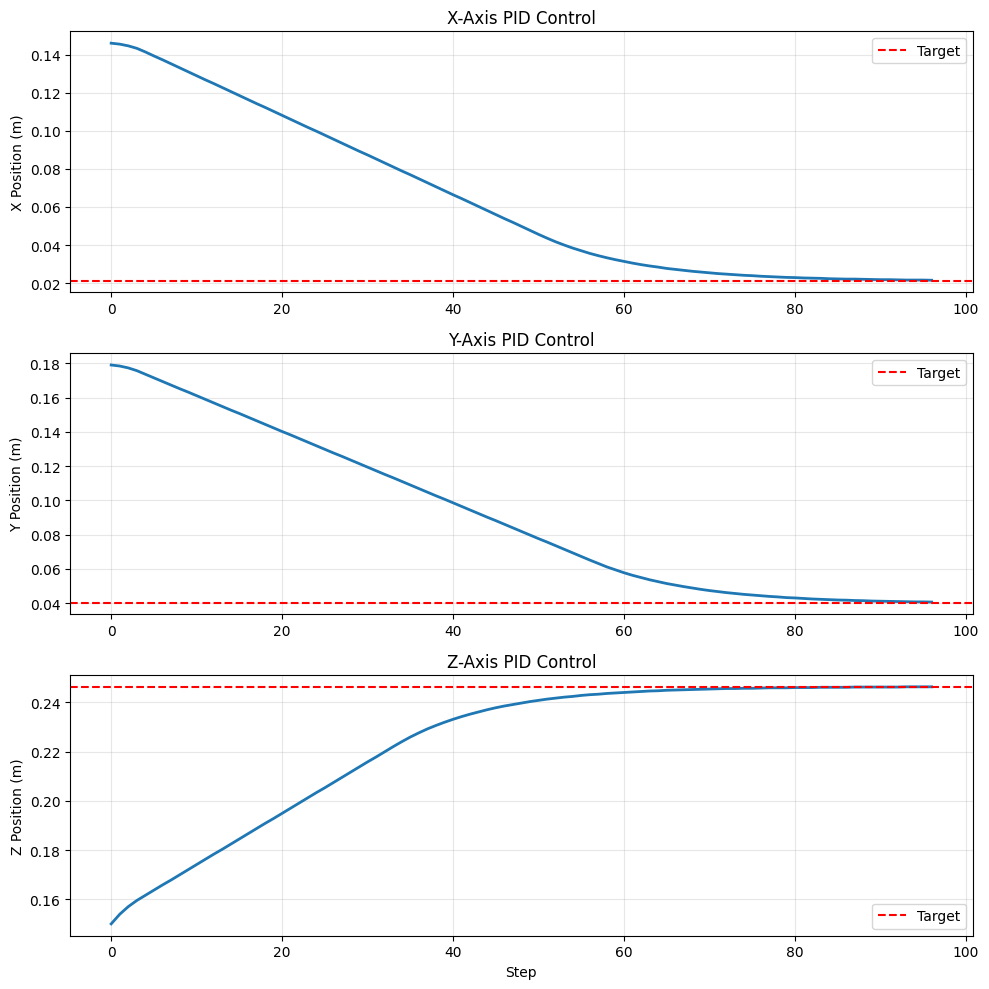

In [8]:
# Visualize all 3 axes
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

ax1.plot(positions_x, linewidth=2)
ax1.axhline(y=target_x, color='r', linestyle='--', label='Target')
ax1.set_ylabel('X Position (m)')
ax1.set_title('X-Axis PID Control')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(positions_y, linewidth=2)
ax2.axhline(y=target_y, color='r', linestyle='--', label='Target')
ax2.set_ylabel('Y Position (m)')
ax2.set_title('Y-Axis PID Control')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(positions_z, linewidth=2)
ax3.axhline(y=target_z, color='r', linestyle='--', label='Target')
ax3.set_xlabel('Step')
ax3.set_ylabel('Z Position (m)')
ax3.set_title('Z-Axis PID Control')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()